#### Цель
Продолжить часть I: добавить ансамбли, настроить их без утечки test-данных и сравнить с baseline, логистической регрессией и одиночным деревом.
#### Данные и формат
Используй тот же датасет UCI, ту же business-постановку и тот же временно безопасный набор признаков. PageValues остаётся исключённым из всех финальных pipeline.  
Достаточно Jupyter-ноутбука. Продолжай тот же репозиторий из части I на ветке clf/online_shoppers/part_2; результат части I сохраняй на clf/online_shoppers/part_1, а требования проекта из части III будут добавлены на clf/online_shoppers/part_3. pyproject.toml и тесты пока не требуются.
#### Задание
* Единый эксперимент: воспроизведи безопасную подготовку данных из части I. Оставь test нетронутым до финальной оценки; все преобразования и подбор параметров должны жить внутри pipeline, который обучается только на train.
* Ансамбли и бустинги: обучи RandomForestClassifier, градиентный бустинг и минимум один библиотечный бустинг: XGBoost, LightGBM или CatBoost. Для CatBoost отдельно объясни, используешь ли нативную обработку категориальных признаков или общий one-hot pipeline. Подбери значимые гиперпараметры через StratifiedKFold и GridSearchCV либо RandomizedSearchCV; обоснуй поисковое пространство и не подбирай параметры по test.
* Сравнение: добавь результаты моделей из части I и новых ансамблей в одну таблицу. Для каждой модели покажи среднюю CV-оценку на train и единственную итоговую оценку на test по PR-AUC, ROC AUC, precision, recall и F1.
* Визуализация и интерпретация: нарисуй ROC- и PR-кривые на общих графиках, а также важность признаков для ансамблей. Если для сравнения важности используешь разные модели, поясни различие между встроенной и permutation importance.
* Бизнес-решение: выбери финальную модель по PR-AUC и объясни, чем она лучше для поиска посетителей, которым стоит предложить скидку или иной стимул. Отдельно опиши, почему версия с PageValues, даже при более высокой offline-оценке, не является допустимой моделью для real-time сценария.

#### 1. Библиотеки и настройки

In [3]:
from pathlib import Path
from io import BytesIO
from urllib.request import urlopen
from zipfile import ZipFile
import hashlib
import platform
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import sklearn

from IPython.display import display, Markdown
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    precision_recall_curve,
    roc_curve,
)
from sklearn.exceptions import ConvergenceWarning

import xgboost
from xgboost import XGBClassifier

In [4]:
RANDOM_STATE = 42
TEST_SIZE = 0.20
N_SPLITS = 5

# Число случайных комбинаций для каждого ансамбля.
# 16 — разумный компромисс между временем и шириной поиска
N_SEARCH_ITER = 16
SEARCH_N_JOBS = -1

warnings.filterwarnings("error", category=ConvergenceWarning)

pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")
plt.rcParams.update({
    "figure.dpi": 110,
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

display(pd.Series({
    "Python": platform.python_version(),
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "scikit-learn": sklearn.__version__,
    "xgboost": xgboost.__version__,
    "matplotlib": matplotlib.__version__,
}, name="Версия").to_frame())

,Версия
Python,3.12.2
numpy,2.5.2
pandas,3.0.5
scikit-learn,1.9.0
xgboost,3.4.1
matplotlib,3.11.1


#### 2. Воспроизводим подготовку данных из части I
Политика признаков полностью сохраняется:
* числовые: 9 признаков;
* категориальные: 7 признаков;
* PageValues исключён;
* точные дубликаты удаляются до split, как в части I;
* train_test_split(..., stratify=y, random_state=42);
* после split test больше нигде не используется до финальной оценки.

In [5]:
DATA_PATH = Path("data/online_shoppers_intention/online_shoppers_intention.csv")
UCI_ZIP_URL = (
    "https://archive.ics.uci.edu/static/public/468/"
    "online+shoppers+purchasing+intention+dataset.zip"
)

candidates = [
    DATA_PATH,
    Path("..") / DATA_PATH,
    Path("online_shoppers_intention.csv"),
    Path("online_shoppers_intention(1).csv"),
    Path("upload/online_shoppers_intention(1).csv"),
]

local_path = next((p for p in candidates if p.is_file()), None)

if local_path is None:
    try:
        with urlopen(UCI_ZIP_URL, timeout=60) as response:
            archive_bytes = response.read()

        with ZipFile(BytesIO(archive_bytes)) as archive:
            member = next(
                name for name in archive.namelist()
                if Path(name).name == "online_shoppers_intention.csv"
            )
            csv_bytes = archive.read(member)

        DATA_PATH.parent.mkdir(parents=True, exist_ok=True)
        DATA_PATH.write_bytes(csv_bytes)
        local_path = DATA_PATH
    except Exception as exc:
        raise RuntimeError(
            f"Не удалось загрузить UCI. Поместите CSV в {DATA_PATH}."
        ) from exc

raw = pd.read_csv(local_path)

print(f"Источник: {local_path.as_posix()}")
print("SHA-256:", hashlib.sha256(local_path.read_bytes()).hexdigest())
print(f"Размер исходной таблицы: {raw.shape[0]:,} x {raw.shape[1]}")

Источник: data/online_shoppers_intention/online_shoppers_intention.csv
SHA-256: b3055ee355f59134d851d32641183cb4a8b45def7124d2f50442a042f358e0d9
Размер исходной таблицы: 12,330 x 18


In [6]:
numeric_features = [
    "Administrative",
    "Administrative_Duration",
    "Informational",
    "Informational_Duration",
    "ProductRelated",
    "ProductRelated_Duration",
    "BounceRates",
    "ExitRates",
    "SpecialDay",
]

categorical_features = [
    "Month",
    "OperatingSystems",
    "Browser",
    "Region",
    "TrafficType",
    "VisitorType",
    "Weekend",
]

feature_columns = numeric_features + categorical_features
expected_columns = set(feature_columns + ["PageValues", "Revenue"])

assert set(raw.columns) == expected_columns, "Неожиданная схема CSV"
assert not raw["Revenue"].isna().any(), "В target есть пропуски"
assert set(raw["Revenue"].unique()) <= {False, True, 0, 1}, "Revenue должна быть бинарной"

# Сохраняем решение части I: удаляем полные дубликаты до split.
data = raw.drop_duplicates().reset_index(drop=True)

X = data[feature_columns].copy()
y = data["Revenue"].astype(int)

# Weekend — категориальный код 0/1. Это фиксированное преобразование без обучения.
X["Weekend"] = X["Weekend"].astype(int)

assert "PageValues" not in X.columns
assert "Revenue" not in X.columns
assert not X.duplicated().any(), (
    "После удаления полных строк остались одинаковые X. "
    "В этом случае нужен групповой split."
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE,
)

assert set(X_train.index).isdisjoint(X_test.index)
assert list(X_train.columns) == feature_columns

# До финального раздела смотрим только train.
train_summary = pd.Series({
    "train rows": len(X_train),
    "test rows (без анализа target)": len(X_test),
    "train purchases": int(y_train.sum()),
    "train positive rate": y_train.mean(),
    "features": X_train.shape[1],
}, name="Значение")
display(train_summary.to_frame())

,Значение
train rows,9764.0000
test rows (без анализа target),2441.0000
train purchases,1526.0000
train positive rate,0.1563
features,16.0000


#### 3. Единый preprocessing и одинаковые folds
Для чисел используется медианная импутация. Для категорий - most-frequent + one-hot encoding.  
Масштабирование требуется логистической регрессии, поэтому StandardScaler включается только в её числовую ветку. Деревьям и бустингам масштабирование не нужно.  
Ключевой принцип: imputer, scaler и encoder находятся внутри Pipeline. Поэтому при CV они обучаются только на train-части соответствующего фолда.  
Все модели используют один и тот же заранее созданный список 5 стратифицированных folds.

In [7]:
def make_preprocessor(*, scale_numeric=False, include_pagevalues=False):
    """Создаёт ColumnTransformer без утечки статистик между фолдами."""
    num_cols = numeric_features + (["PageValues"] if include_pagevalues else [])

    num_steps = [("imputer", SimpleImputer(strategy="median"))]
    if scale_numeric:
        num_steps.append(("scaler", StandardScaler()))

    numeric_pipeline = Pipeline(num_steps)

    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False,
            ),
        ),
    ])

    return ColumnTransformer(
        transformers=[
            ("num", numeric_pipeline, num_cols),
            ("cat", categorical_pipeline, categorical_features),
        ],
        remainder="drop",
    )


def make_pipeline(model, *, scale_numeric=False, include_pagevalues=False):
    """Оборачивает preprocessing и классификатор в единый Pipeline."""
    return Pipeline([
        (
            "preprocessor",
            make_preprocessor(
                scale_numeric=scale_numeric,
                include_pagevalues=include_pagevalues,
            ),
        ),
        ("model", model),
    ])


cv = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE,
)
folds = list(cv.split(X_train, y_train))

# Проверка: каждый объект train ровно один раз попадает в validation.
validation_hits = np.zeros(len(X_train), dtype=int)
for _, valid_idx in folds:
    validation_hits[valid_idx] += 1

assert np.all(validation_hits == 1)
print(f"Зафиксировано {len(folds)} одинаковых folds для всех моделей.")

Зафиксировано 5 одинаковых folds для всех моделей.


#### 4. Модели части I: baseline, LogisticRegression и одиночное дерево
Параметры логистической регрессии и дерева оставлены такими же, как в части I

In [8]:
part1_models = {
    "Dummy (prior)": make_pipeline(
        DummyClassifier(strategy="prior"),
    ),
    "LogisticRegression": make_pipeline(
        LogisticRegression(
            C=1.0,
            solver="lbfgs",
            max_iter=3000,
            random_state=RANDOM_STATE,
        ),
        scale_numeric=True,
    ),
    "DecisionTree": make_pipeline(
        DecisionTreeClassifier(
            max_depth=5,
            min_samples_leaf=50,
            random_state=RANDOM_STATE,
        ),
    ),
}

list(part1_models)

['Dummy (prior)', 'LogisticRegression', 'DecisionTree']

#### 5. Ансамбли и пространство гиперпараметров
Подбор выполняется только на train. RandomizedSearchCV выбран вместо полного grid: пространства уже многомерные, а полный перебор дал бы много дорогих комбинаций с малой дополнительной пользой.  
Основной scoring="average_precision" соответствует выбранной бизнес-метрике PR-AUC/AP.  
Для XGBoost используется тот же общий one-hot pipeline, а не нативная обработка категорий. Это делает preprocessing одинаковым и сравнение моделей понятнее.

In [9]:
negative_positive_ratio = (
    (y_train == 0).sum() / (y_train == 1).sum()
)

ensemble_estimators = {
    "RandomForest": make_pipeline(
        RandomForestClassifier(
            random_state=RANDOM_STATE,
            n_jobs=1,  # параллелизм отдаём RandomizedSearchCV
        )
    ),
    "GradientBoosting": make_pipeline(
        GradientBoostingClassifier(
            random_state=RANDOM_STATE,
        )
    ),
    "XGBoost": make_pipeline(
        XGBClassifier(
            objective="binary:logistic",
            eval_metric="logloss",
            tree_method="hist",
            importance_type="gain",
            random_state=RANDOM_STATE,
            n_jobs=1,
            verbosity=0,
        )
    ),
}

search_spaces = {
    "RandomForest": {
        "model__n_estimators": [250, 400, 600, 800],
        "model__max_depth": [None, 8, 12, 18],
        "model__min_samples_leaf": [1, 2, 5, 10],
        "model__max_features": ["sqrt", 0.5, None],
        "model__class_weight": [None, "balanced_subsample"],
    },
    "GradientBoosting": {
        "model__n_estimators": [100, 180, 260, 360],
        "model__learning_rate": [0.025, 0.05, 0.08, 0.12],
        "model__max_depth": [1, 2, 3],
        "model__min_samples_leaf": [10, 20, 40, 80],
        "model__subsample": [0.70, 0.85, 1.00],
    },
    "XGBoost": {
        "model__n_estimators": [200, 350, 500, 700],
        "model__learning_rate": [0.025, 0.05, 0.08, 0.12],
        "model__max_depth": [2, 3, 4, 5],
        "model__min_child_weight": [1, 3, 5, 8],
        "model__subsample": [0.70, 0.85, 1.00],
        "model__colsample_bytree": [0.70, 0.85, 1.00],
        "model__reg_lambda": [1.0, 3.0, 8.0, 15.0],
        "model__scale_pos_weight": [1.0, float(negative_positive_ratio)],
    },
}

print(f"Отношение negative / positive в train: {negative_positive_ratio:.3f}")

Отношение negative / positive в train: 5.398


In [10]:
searches = {}
best_ensemble_models = {}
search_rows = []

for name, estimator in ensemble_estimators.items():
    print(f"\n===== {name} =====")

    search = RandomizedSearchCV(
        estimator=estimator,
        param_distributions=search_spaces[name],
        n_iter=N_SEARCH_ITER,
        scoring="average_precision",
        cv=folds,
        refit=True,
        random_state=RANDOM_STATE,
        n_jobs=SEARCH_N_JOBS,
        return_train_score=True,
        verbose=1,
    )

    started = time.perf_counter()
    search.fit(X_train, y_train)
    elapsed = time.perf_counter() - started

    searches[name] = search
    best_ensemble_models[name] = search.best_estimator_

    search_rows.append({
        "Модель": name,
        "Best CV PR-AUC": search.best_score_,
        "Search time, s": elapsed,
        "Best params": search.best_params_,
    })

search_summary = pd.DataFrame(search_rows).set_index("Модель")
display(search_summary)


===== RandomForest =====
Fitting 5 folds for each of 16 candidates, totalling 80 fits

===== GradientBoosting =====
Fitting 5 folds for each of 16 candidates, totalling 80 fits

===== XGBoost =====
Fitting 5 folds for each of 16 candidates, totalling 80 fits


,Best CV PR-AUC,"Search time, s",Best params
Модель,,,
RandomForest,0.3821,697.7713,"{'model__n_estimators': 600, 'model__min_sampl..."
GradientBoosting,0.3738,278.9939,"{'model__subsample': 0.85, 'model__n_estimator..."
XGBoost,0.3792,67.3218,"{'model__subsample': 0.85, 'model__scale_pos_w..."


best_score_ — средний validation PR-AUC по тем же пяти train-folds. Test на этом этапе всё ещё не используется.  
Поскольку гиперпараметры выбирались по этим же folds, CV-оценка tuned-моделей является оценкой этапа model selection, а не полностью независимой nested-CV оценкой. Для этой задачи внешний нетронутый holdout остаётся окончательной проверкой.

#### 6. OOF-предсказания, CV-метрики и пороги - только на train

In [11]:
all_models = {
    **part1_models,
    **best_ensemble_models,
}


def collect_oof_probabilities(pipeline, features, target, splits):
    """
    Строит OOF-вероятности:
    каждую строку предсказывает модель, которая эту строку не видела при fit.
    """
    oof = np.full(len(target), np.nan, dtype=float)
    fold_rows = []

    for fold, (fit_idx, valid_idx) in enumerate(splits, start=1):
        fitted = clone(pipeline).fit(
            features.iloc[fit_idx],
            target.iloc[fit_idx],
        )
        probability = fitted.predict_proba(
            features.iloc[valid_idx]
        )[:, 1]

        oof[valid_idx] = probability

        fold_rows.append({
            "Fold": fold,
            "PR_AUC": average_precision_score(
                target.iloc[valid_idx], probability
            ),
            "ROC_AUC": roc_auc_score(
                target.iloc[valid_idx], probability
            ),
        })

    assert np.isfinite(oof).all()
    return oof, pd.DataFrame(fold_rows)


def best_f1_threshold(y_true, probability):
    """Находит порог максимального F1 по train OOF-предсказаниям."""
    precision, recall, thresholds = precision_recall_curve(
        y_true, probability
    )

    f1_values = np.divide(
        2 * precision[:-1] * recall[:-1],
        precision[:-1] + recall[:-1],
        out=np.zeros_like(thresholds),
        where=(precision[:-1] + recall[:-1]) > 0,
    )

    best_indices = np.flatnonzero(
        np.isclose(
            f1_values,
            f1_values.max(),
            rtol=0,
            atol=1e-12,
        )
    )

    # При равном F1 берём больший порог:
    # не расширяем число показов без выигрыша F1.
    return float(thresholds[best_indices[-1]])


def fold_threshold_summary(oof, target, splits, threshold):
    """Средние precision/recall/F1 по validation-folds при фиксированном пороге."""
    rows = []

    for fold, (_, valid_idx) in enumerate(splits, start=1):
        y_valid = target.iloc[valid_idx]
        predicted = (oof[valid_idx] >= threshold).astype(int)

        rows.append({
            "Fold": fold,
            "precision": precision_score(
                y_valid, predicted, zero_division=0
            ),
            "recall": recall_score(
                y_valid, predicted, zero_division=0
            ),
            "F1": f1_score(
                y_valid, predicted, zero_division=0
            ),
        })

    return pd.DataFrame(rows)


oof_probabilities = {}
cv_probability_details = {}
thresholds = {}
cv_rows = []

for name, pipeline in all_models.items():
    print(f"OOF: {name}")

    oof, probability_details = collect_oof_probabilities(
        pipeline,
        X_train,
        y_train,
        folds,
    )

    oof_probabilities[name] = oof
    cv_probability_details[name] = probability_details

    # Dummy оставляем фиксированным baseline без оптимизации порога.
    threshold = (
        0.5
        if name == "Dummy (prior)"
        else best_f1_threshold(y_train, oof)
    )
    thresholds[name] = threshold

    threshold_details = fold_threshold_summary(
        oof,
        y_train,
        folds,
        threshold,
    )

    cv_rows.append({
        "Модель": name,
        "CV_PR_AUC_mean": probability_details["PR_AUC"].mean(),
        "CV_PR_AUC_std": probability_details["PR_AUC"].std(ddof=1),
        "CV_ROC_AUC_mean": probability_details["ROC_AUC"].mean(),
        "CV_precision_mean": threshold_details["precision"].mean(),
        "CV_recall_mean": threshold_details["recall"].mean(),
        "CV_F1_mean": threshold_details["F1"].mean(),
        "OOF_threshold": threshold,
    })

cv_summary = (
    pd.DataFrame(cv_rows)
    .set_index("Модель")
    .sort_values("CV_PR_AUC_mean", ascending=False)
)

display(cv_summary)

OOF: Dummy (prior)
OOF: LogisticRegression
OOF: DecisionTree
OOF: RandomForest
OOF: GradientBoosting
OOF: XGBoost


,CV_PR_AUC_mean,CV_PR_AUC_std,CV_ROC_AUC_mean,CV_precision_mean,CV_recall_mean,CV_F1_mean,OOF_threshold
Модель,,,,,,,
RandomForest,0.3821,0.0319,0.7756,0.3060,0.6920,0.4243,0.1901
XGBoost,0.3792,0.0286,0.7774,0.3428,0.6179,0.4408,0.2133
GradientBoosting,0.3738,0.0243,0.7756,0.3338,0.6094,0.4310,0.2062
LogisticRegression,0.3278,0.0299,0.7434,0.2772,0.6710,0.3923,0.1757
DecisionTree,0.3252,0.0199,0.7392,0.3209,0.5111,0.3931,0.2303
Dummy (prior),0.1563,0.0002,0.5000,0.0000,0.0000,0.0000,0.5000


Порог каждой реальной модели найден только по OOF-предсказаниям train и затем фиксируется. Это продолжает бизнес-логику части I: ранжирование моделей выполняется по PR-AUC, а бинарное решение «показывать стимул / не показывать» требует отдельного порога.  
У Dummy (prior) порог специально не оптимизируется: он остаётся простым контрольным baseline с t=0.5.

#### 7. Финальная модель до test

In [12]:
candidate_names = [
    name for name in all_models
    if name != "Dummy (prior)"
]

selected_name = (
    cv_summary
    .loc[candidate_names, "CV_PR_AUC_mean"]
    .idxmax()
)

selected_pipeline = all_models[selected_name]
selected_threshold = thresholds[selected_name]

print("Финальная модель по train CV PR-AUC:", selected_name)
print(
    "CV PR-AUC:",
    f"{cv_summary.loc[selected_name, 'CV_PR_AUC_mean']:.4f}"
)
print("Зафиксированный OOF-порог:", f"{selected_threshold:.6f}")

# После этой ячейки модель, гиперпараметры и threshold считаем зафиксированными.

Финальная модель по train CV PR-AUC: RandomForest
CV PR-AUC: 0.3821
Зафиксированный OOF-порог: 0.190112


#### 8. Диагностика PageValues - только train, не для выбора
Диагностическа из части I для выбранного алгоритма: тот же классификатор и те же folds, но временно добавляем PageValues в числовую ветку.  
Наша цель диагностики - показать, насколько сильным является признак, который недоступен в требуемый момент real-time решения.

In [13]:
X_train_pagevalues = X_train.assign(
    PageValues=data.loc[X_train.index, "PageValues"]
)

selected_model_only = clone(
    selected_pipeline.named_steps["model"]
)

selected_with_pagevalues = make_pipeline(
    selected_model_only,
    scale_numeric=(selected_name == "LogisticRegression"),
    include_pagevalues=True,
)

oof_with_pagevalues, details_with_pagevalues = collect_oof_probabilities(
    selected_with_pagevalues,
    X_train_pagevalues,
    y_train,
    folds,
)

pagevalues_diagnostic = pd.DataFrame({
    "CV PR-AUC mean": [
        cv_summary.loc[selected_name, "CV_PR_AUC_mean"],
        details_with_pagevalues["PR_AUC"].mean(),
    ],
    "OOF PR-AUC": [
        average_precision_score(
            y_train,
            oof_probabilities[selected_name],
        ),
        average_precision_score(
            y_train,
            oof_with_pagevalues,
        ),
    ],
}, index=[
    f"{selected_name} без PageValues",
    f"{selected_name} с PageValues (диагностика)",
])

display(pagevalues_diagnostic)

assert "PageValues" not in X_train.columns
assert "PageValues" not in X_test.columns

,CV PR-AUC mean,OOF PR-AUC
RandomForest без PageValues,0.3821,0.3731
RandomForest с PageValues (диагностика),0.7481,0.7467


Высокая offline-оценка с PageValues не спасает модель:  
Метрика отвечает на вопрос «насколько хорошо модель предсказывает при наличии этих входов». Нет проверки, что существовал ли каждый вход в момент бизнес-решения.  
Если PageValues формируется или существенно уточняется после дальнейших действий пользователя, то при раннем показе скидки такого значения ещё нет. Использование признака даёт модели информацию из будущего относительно момента скоринга. Поэтому это временная утечка / недопустимый proxy для real-time сценария.  
!!!!!!Правильное решение - принять более низкую, но честную offline-метрику модели, которая использует только признаки, реально доступные в момент скоринга.

#### 9. Финальная оценка на test
До этой точки y_test не участвовал:
* ни в preprocessing;
* ни в выборе гиперпараметров;
* ни в выборе алгоритма;
* ни в выборе threshold;
* ни в диагностике PageValues.

Теперь каждая зафиксированная модель обучается на всём train и один раз получает вероятности на test. Эти же сохранённые вероятности затем используются и для таблицы, и для ROC/PR-кривых (без новых подгонок по test).

In [14]:
def evaluate_probabilities(y_true, probability, threshold):
    """Метрики по вероятностям и по бинарным решениям при фиксированном threshold."""
    predicted = (probability >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        predicted,
        labels=[0, 1],
    ).ravel()

    return {
        "PR_AUC": average_precision_score(y_true, probability),
        "ROC_AUC": roc_auc_score(y_true, probability),
        "precision": precision_score(y_true, predicted, zero_division=0),
        "recall": recall_score(y_true, predicted, zero_division=0),
        "F1": f1_score(y_true, predicted, zero_division=0),
        "threshold": float(threshold),
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "TP": int(tp),
        "Показов": int(tp + fp),
        "Доля показов": float(predicted.mean()),
    }


fitted_models = {}
test_probabilities = {}
test_rows = []

for name, pipeline in all_models.items():
    fitted = clone(pipeline).fit(X_train, y_train)
    probability = fitted.predict_proba(X_test)[:, 1]

    fitted_models[name] = fitted
    test_probabilities[name] = probability

    test_rows.append({
        "Модель": name,
        **evaluate_probabilities(
            y_test,
            probability,
            thresholds[name],
        ),
    })

test_summary = pd.DataFrame(test_rows).set_index("Модель")

comparison = cv_summary.join(
    test_summary.add_prefix("Test_"),
    how="left",
)

display(
    comparison[[
        "CV_PR_AUC_mean",
        "CV_ROC_AUC_mean",
        "CV_precision_mean",
        "CV_recall_mean",
        "CV_F1_mean",
        "OOF_threshold",
        "Test_PR_AUC",
        "Test_ROC_AUC",
        "Test_precision",
        "Test_recall",
        "Test_F1",
    ]]
)

,CV_PR_AUC_mean,CV_ROC_AUC_mean,CV_precision_mean,CV_recall_mean,CV_F1_mean,OOF_threshold,Test_PR_AUC,Test_ROC_AUC,Test_precision,Test_recall,Test_F1
Модель,,,,,,,,,,,
RandomForest,0.3821,0.7756,0.3060,0.6920,0.4243,0.1901,0.3828,0.7876,0.3071,0.7147,0.4296
XGBoost,0.3792,0.7774,0.3428,0.6179,0.4408,0.2133,0.3781,0.7929,0.3493,0.6309,0.4496
GradientBoosting,0.3738,0.7756,0.3338,0.6094,0.4310,0.2062,0.3621,0.7878,0.3394,0.6309,0.4414
LogisticRegression,0.3278,0.7434,0.2772,0.6710,0.3923,0.1757,0.3325,0.7537,0.2881,0.7120,0.4103
DecisionTree,0.3252,0.7392,0.3209,0.5111,0.3931,0.2303,0.3086,0.7349,0.3048,0.5026,0.3794
Dummy (prior),0.1563,0.5000,0.0000,0.0000,0.0000,0.5000,0.1565,0.5000,0.0000,0.0000,0.0000


итоги:  
* CV_* — средние validation-метрики по пяти folds внутри train;
* OOF_threshold — рабочий порог, выбранный без test;
* Test_* — одна итоговая проверка на holdout;
* модель выбиралась не по Test_PR_AUC, а ранее по CV_PR_AUC_mean.  

PR-AUC/AP — основная метрика, потому что положительный класс редкий и бизнесу важно одновременно: находить покупателей (recall) и не раздавать стимул слишком большому числу непокупателей (precision).

#### 10. Общие PR- и ROC-кривые на test

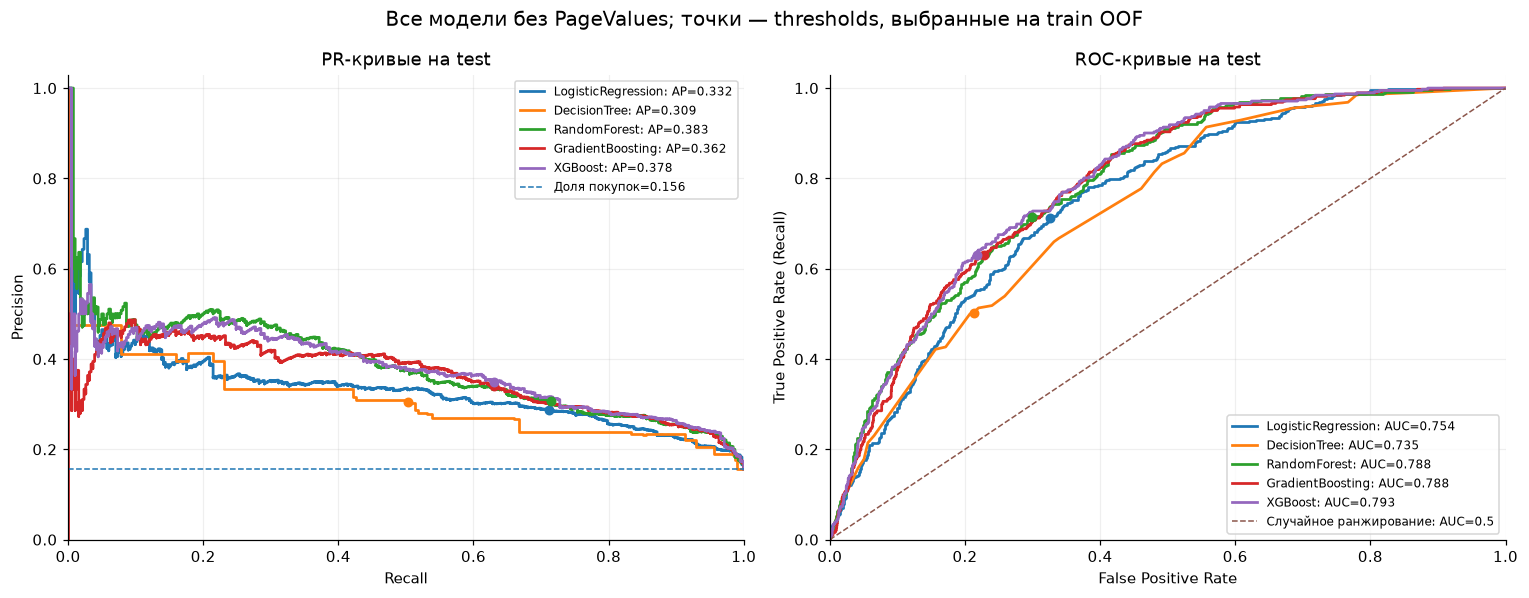

In [15]:
curve_names = [
    "LogisticRegression",
    "DecisionTree",
    "RandomForest",
    "GradientBoosting",
    "XGBoost",
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

for name in curve_names:
    probability = test_probabilities[name]

    precision, recall, _ = precision_recall_curve(y_test, probability)
    fpr, tpr, _ = roc_curve(y_test, probability)

    axes[0].step(
        recall,
        precision,
        where="post",
        linewidth=1.8,
        label=f"{name}: AP={average_precision_score(y_test, probability):.3f}",
    )

    axes[1].plot(
        fpr,
        tpr,
        linewidth=1.8,
        label=f"{name}: AUC={roc_auc_score(y_test, probability):.3f}",
    )

    result = evaluate_probabilities(
        y_test,
        probability,
        thresholds[name],
    )

    axes[0].scatter(
        result["recall"],
        result["precision"],
        s=30,
        zorder=5,
    )

    false_positive_rate = (
        result["FP"] / (result["FP"] + result["TN"])
        if (result["FP"] + result["TN"]) > 0
        else 0.0
    )

    axes[1].scatter(
        false_positive_rate,
        result["recall"],
        s=30,
        zorder=5,
    )

axes[0].axhline(
    y_test.mean(),
    linestyle="--",
    linewidth=1,
    label=f"Доля покупок={y_test.mean():.3f}",
)

axes[1].plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1,
    label="Случайное ранжирование: AUC=0.5",
)

axes[0].set(
    xlabel="Recall",
    ylabel="Precision",
    title="PR-кривые на test",
    xlim=(0, 1),
    ylim=(0, 1.03),
)

axes[1].set(
    xlabel="False Positive Rate",
    ylabel="True Positive Rate (Recall)",
    title="ROC-кривые на test",
    xlim=(0, 1),
    ylim=(0, 1.03),
)

for ax in axes:
    ax.grid(alpha=0.2)
    ax.legend(loc="best", fontsize=8)

fig.suptitle(
    "Все модели без PageValues; точки — thresholds, выбранные на train OOF",
    fontsize=13,
)
fig.tight_layout()
plt.show()

#### 11. Встроенная важность признаков ансамблей
У деревьев есть feature_importances_, но после one-hot один исходный категориальный признак превращается в несколько бинарных столбцов. Поэтому ниже важности one-hot столбцов суммируются обратно до исходных 16 признаков.  
Это позволяет сравнивать общую роль Month, TrafficType, VisitorType и т. п., а не отдельные dummy-категории.

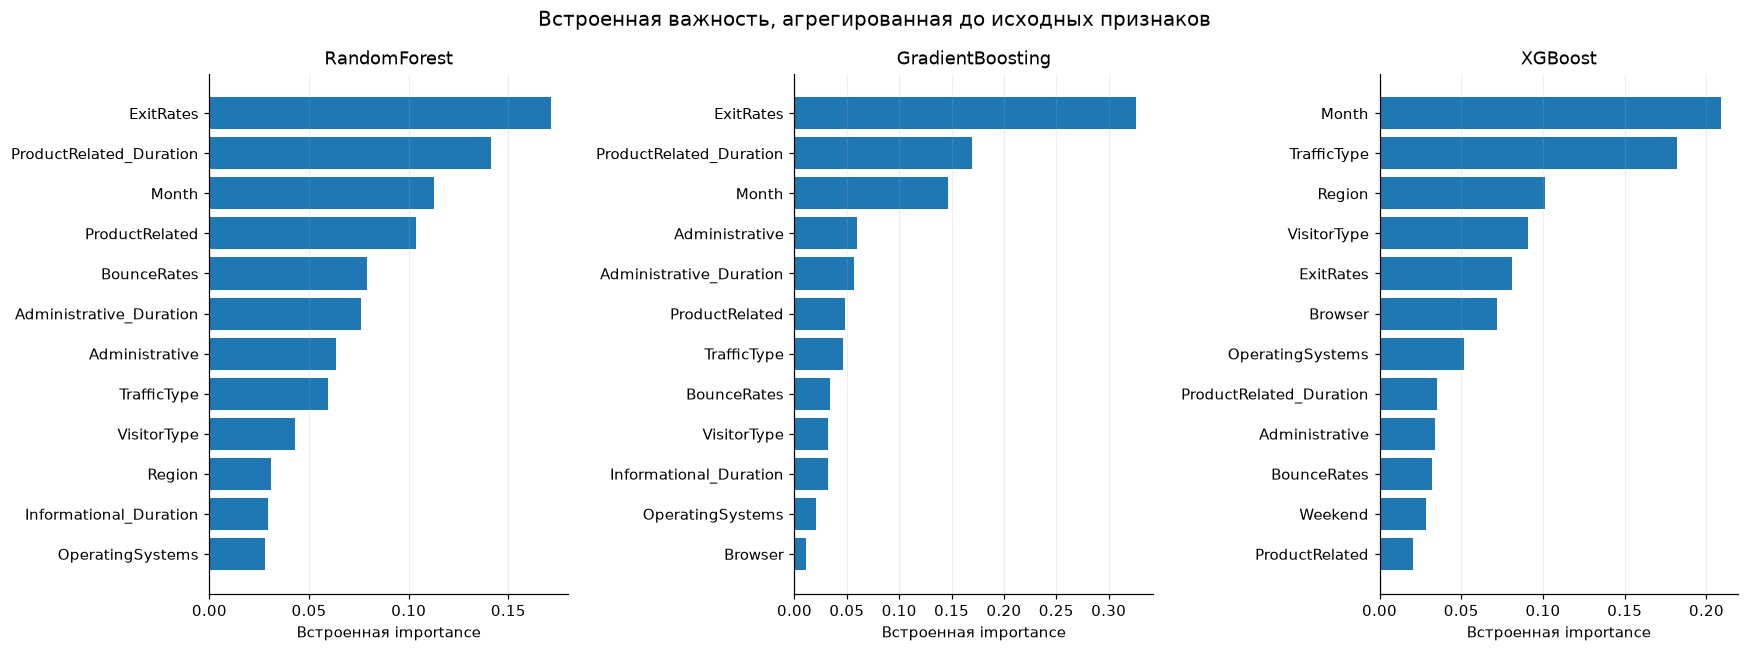

In [16]:
def aggregate_builtin_importance(fitted_pipeline):
    """
    Агрегирует feature_importances_ от transformed columns
    обратно к исходным признакам.
    """
    model = fitted_pipeline.named_steps["model"]
    preprocessor = fitted_pipeline.named_steps["preprocessor"]

    if not hasattr(model, "feature_importances_"):
        raise TypeError(
            f"{type(model).__name__} не имеет feature_importances_"
        )

    importances = np.asarray(
        model.feature_importances_,
        dtype=float,
    )

    original_names = list(numeric_features)

    encoder = (
        preprocessor
        .named_transformers_["cat"]
        .named_steps["encoder"]
    )

    for column, categories in zip(
        categorical_features,
        encoder.categories_,
    ):
        original_names.extend([column] * len(categories))

    assert len(original_names) == len(importances), (
        len(original_names),
        len(importances),
    )

    return (
        pd.Series(
            importances,
            index=original_names,
            name="importance",
        )
        .groupby(level=0)
        .sum()
        .sort_values(ascending=False)
    )


ensemble_names = [
    "RandomForest",
    "GradientBoosting",
    "XGBoost",
]

builtin_importances = {
    name: aggregate_builtin_importance(
        fitted_models[name]
    )
    for name in ensemble_names
}

fig, axes = plt.subplots(
    1,
    3,
    figsize=(16, 6),
    sharey=False,
)

for ax, name in zip(axes, ensemble_names):
    top = (
        builtin_importances[name]
        .head(12)
        .sort_values()
    )

    ax.barh(top.index, top.values)
    ax.set_title(name)
    ax.set_xlabel("Встроенная importance")
    ax.grid(axis="x", alpha=0.2)

fig.suptitle(
    "Встроенная важность, агрегированная до исходных признаков",
    fontsize=13,
)
fig.tight_layout()
plt.show()

Встроенная importance и permutation importance — это не одно и то же.  
Permutation importance ниже считается только для уже выбранной финальной модели и не влияет на её выбор.

,feature,importance_mean,importance_std
0,Month,0.0728,0.0217
1,ProductRelated_Duration,0.0464,0.0142
2,ExitRates,0.0398,0.0163
3,VisitorType,0.0221,0.0063
4,ProductRelated,0.0134,0.0115
5,BounceRates,0.0123,0.0066
6,Administrative,0.0091,0.0044
7,TrafficType,0.0062,0.0040
8,Administrative_Duration,0.0061,0.0045
9,OperatingSystems,0.0045,0.0035


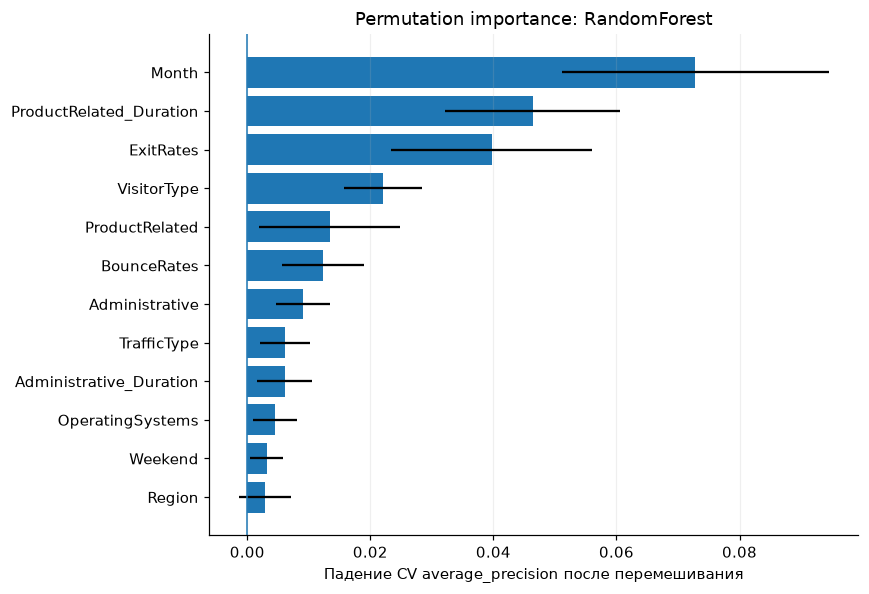

In [17]:
def cv_permutation_importance(
    pipeline,
    features,
    target,
    splits,
    *,
    n_repeats=8,
):
    """
    Permutation importance на validation-части каждого train-fold.
    Возвращает среднее снижение average_precision.
    """
    fold_importances = []

    for fold, (fit_idx, valid_idx) in enumerate(
        splits,
        start=1,
    ):
        fitted = clone(pipeline).fit(
            features.iloc[fit_idx],
            target.iloc[fit_idx],
        )

        result = permutation_importance(
            fitted,
            features.iloc[valid_idx],
            target.iloc[valid_idx],
            scoring="average_precision",
            n_repeats=n_repeats,
            random_state=RANDOM_STATE + fold,
            n_jobs=SEARCH_N_JOBS,
        )

        fold_importances.append(
            result.importances_mean
        )

    matrix = np.vstack(fold_importances)

    return (
        pd.DataFrame({
            "feature": features.columns,
            "importance_mean": matrix.mean(axis=0),
            "importance_std": matrix.std(axis=0, ddof=1),
        })
        .sort_values(
            "importance_mean",
            ascending=False,
        )
        .reset_index(drop=True)
    )


selected_permutation = cv_permutation_importance(
    selected_pipeline,
    X_train,
    y_train,
    folds,
    n_repeats=8,
)

display(selected_permutation)

top_perm = (
    selected_permutation
    .head(12)
    .sort_values("importance_mean")
)

plt.figure(figsize=(8, 5.5))
plt.barh(
    top_perm["feature"],
    top_perm["importance_mean"],
    xerr=top_perm["importance_std"],
)
plt.axvline(0, linewidth=1)
plt.xlabel("Падение CV average_precision после перемешивания")
plt.title(f"Permutation importance: {selected_name}")
plt.grid(axis="x", alpha=0.2)
plt.tight_layout()
plt.show()

#### 12. Бизнес-решение

In [18]:
selected_test = test_summary.loc[selected_name]
selected_cv = cv_summary.loc[selected_name]

display(Markdown(
    f"""
### Финальная модель: **{selected_name}**

Она выбрана **до test** по максимальному среднему CV PR-AUC на train:

- CV PR-AUC = **{selected_cv['CV_PR_AUC_mean']:.3f}**;
- test PR-AUC = **{selected_test['PR_AUC']:.3f}**;
- test ROC AUC = **{selected_test['ROC_AUC']:.3f}**;
- рабочий threshold из train OOF = **{selected_test['threshold']:.3f}**;
- test precision = **{selected_test['precision']:.1%}**;
- test recall = **{selected_test['recall']:.1%}**;
- test F1 = **{selected_test['F1']:.3f}**;
- найдено покупателей: **{int(selected_test['TP'])}**;
- пропущено покупателей: **{int(selected_test['FN'])}**;
- стимул показан непокупателям: **{int(selected_test['FP'])}**;
- всего показов стимула: **{int(selected_test['Показов'])}**
  ({selected_test['Доля показов']:.1%} test-сессий).

"""
))


### Финальная модель: **RandomForest**

Она выбрана **до test** по максимальному среднему CV PR-AUC на train:

- CV PR-AUC = **0.382**;
- test PR-AUC = **0.383**;
- test ROC AUC = **0.788**;
- рабочий threshold из train OOF = **0.190**;
- test precision = **30.7%**;
- test recall = **71.5%**;
- test F1 = **0.430**;
- найдено покупателей: **273**;
- пропущено покупателей: **109**;
- стимул показан непокупателям: **616**;
- всего показов стимула: **889**
  (36.4% test-сессий).

